# Cas9 DMS Activity Prediction
## Step 3 — Baseline Models

### Objective

Establish simple predictive baselines before introducing pretrained protein
sequence representations.

The target is `DMS_score`, a continuous activity-related phenotype from the
Cas9 deep mutational scanning assay.

We evaluate the baselines under two evaluation protocols:

### 1. Position-held-out split — Primary

Mutations are grouped by Cas9 residue position.

No residue position is shared between train, validation and test.

This tests whether the model can generalize to mutations at positions that
were not observed during training.

### 2. Random mutation split — Secondary

Individual mutations are divided randomly into train, validation and test.

Different mutations from the same residue position may occur in different
splits.

This measures interpolation to new substitutions at positions that may
already have been represented during training.

### Models

We establish three simple baselines:

1. Global mean
2. Amino-acid substitution
3. Amino-acid substitution + sequence position

Validation data are used to select the Ridge regularization parameter.

The primary test set is kept untouched until final evaluation.

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from scipy.stats import pearsonr, spearmanr

SEED = 42

In [52]:
def find_project_root(start_path):
    start_path = Path(start_path).resolve()

    for path in [start_path, *start_path.parents]:
        if (path / "data").is_dir() and (path / "notebooks").is_dir():
            return path

    raise FileNotFoundError(
        "Could not find Mandrake-Bio project root."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

print("Project root:", PROJECT_ROOT)
print("Results directory:", RESULTS_DIR)

Project root: C:\Users\subha\OneDrive\Desktop\Mandrake_Ai_Bio_research\Mandrake_Cas9_Assignment_Pack\Mandrake-Bio
Results directory: C:\Users\subha\OneDrive\Desktop\Mandrake_Ai_Bio_research\Mandrake_Cas9_Assignment_Pack\Mandrake-Bio\results


In [53]:
PROCESSED_DATA_PATH = (
    RESULTS_DIR / "processed_cas9_dms.csv"
)

df = pd.read_csv(PROCESSED_DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (8117, 7)


,mutant,mutated_sequence,DMS_score,DMS_score_bin,wt_residue,position,mutant_residue
0,A1023D,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.620198,0,A,1023,D
1,A1023G,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.424130,0,A,1023,G
2,A1023P,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.626792,0,A,1023,P
3,A1023S,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.490423,0,A,1023,S
4,A1023T,MDKKYSIGLDIGTNSVGWAVITDEYKVPSKKFKVLGNTDRHSIKKN...,-0.543741,0,A,1023,T


In [54]:
POSITION_SPLIT_PATH = (
    RESULTS_DIR / "position_split_assignments.csv"
)

RANDOM_SPLIT_PATH = (
    RESULTS_DIR / "random_split_assignments.csv"
)

position_splits = pd.read_csv(
    POSITION_SPLIT_PATH
)

random_splits = pd.read_csv(
    RANDOM_SPLIT_PATH
)

print("Position split:")
display(position_splits.head())

print("\nRandom split:")
display(random_splits.head())

Position split:


,mutant,position,split
0,A1023D,1023,test
1,A1023G,1023,test
2,A1023P,1023,test
3,A1023S,1023,test
4,A1023T,1023,test



Random split:


,mutant,position,split
0,A1023D,1023,train
1,A1023G,1023,test
2,A1023P,1023,train
3,A1023S,1023,train
4,A1023T,1023,test


In [55]:
df_position = df.merge(
    position_splits[["mutant", "split"]],
    on="mutant",
    how="inner"
)

train_pos = df_position[
    df_position["split"] == "train"
].copy()

val_pos = df_position[
    df_position["split"] == "validation"
].copy()

test_pos = df_position[
    df_position["split"] == "test"
].copy()

print("Position-held-out split")
print("-----------------------")
print("Train:", len(train_pos))
print("Validation:", len(val_pos))
print("Test:", len(test_pos))

Position-held-out split
-----------------------
Train: 6490
Validation: 810
Test: 817


In [56]:
df_random = df.merge(
    random_splits[["mutant", "split"]],
    on="mutant",
    how="inner"
)

train_rand = df_random[
    df_random["split"] == "train"
].copy()

val_rand = df_random[
    df_random["split"] == "validation"
].copy()

test_rand = df_random[
    df_random["split"] == "test"
].copy()

print("Random mutation split")
print("---------------------")
print("Train:", len(train_rand))
print("Validation:", len(val_rand))
print("Test:", len(test_rand))

Random mutation split
---------------------
Train: 6493
Validation: 812
Test: 812


In [57]:
# Create the mutation-substitution feature.
# Example:
# A1023D -> A->D

for frame in [
    train_pos,
    val_pos,
    test_pos,
    train_rand,
    val_rand,
    test_rand
]:
    frame["substitution"] = (
        frame["wt_residue"]
        + "->"
        + frame["mutant_residue"]
    )

display(
    train_pos[
        [
            "mutant",
            "wt_residue",
            "position",
            "mutant_residue",
            "substitution",
            "DMS_score"
        ]
    ].head(10)
)

,mutant,wt_residue,position,mutant_residue,substitution,DMS_score
6,A1032D,A,1032,D,A->D,-0.104925
7,A1032G,A,1032,G,A->G,-0.055298
8,A1032P,A,1032,P,A->P,-1.473927
9,A1032S,A,1032,S,A->S,-0.198013
10,A1032T,A,1032,T,A->T,1.710928
11,A1032V,A,1032,V,A->V,-0.368924
12,A1034D,A,1034,D,A->D,0.372312
13,A1034G,A,1034,G,A->G,-0.874441
14,A1034P,A,1034,P,A->P,-0.130606
15,A1034S,A,1034,S,A->S,-0.474870


In [58]:
import numpy as np
import warnings

def regression_metrics(y_true, y_pred):
    """
    Calculate regression metrics safely.

    Pearson and Spearman correlations are undefined when either
    input is constant or contains non-finite values.
    """

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    # Check for invalid or constant arrays
    valid_values = (
        np.isfinite(y_true).all()
        and np.isfinite(y_pred).all()
    )

    y_true_constant = (
        y_true.size == 0
        or np.ptp(y_true) == 0
    )

    y_pred_constant = (
        y_pred.size == 0
        or np.ptp(y_pred) == 0
    )

    if (
        not valid_values
        or y_true_constant
        or y_pred_constant
    ):
        pearson = np.nan
        spearman = np.nan

    else:
        # Extra protection against scipy warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            pearson = pearsonr(
                y_true,
                y_pred
            ).statistic

            spearman = spearmanr(
                y_true,
                y_pred
            ).statistic

    return {
        "RMSE": rmse,
        "MAE": mae,
        "Pearson": pearson,
        "Spearman": spearman,
        "R2": r2
    }

## Baseline 0 — Global Mean

The global-mean baseline predicts the mean activity score observed in the
training set for every evaluation mutation.

This is the simplest possible regression baseline.

The training mean is calculated using the training data only.

In [59]:
def mean_baseline(train_df, eval_df):
    mean_score = train_df["DMS_score"].mean()

    predictions = np.full(
        len(eval_df),
        mean_score
    )

    metrics = regression_metrics(
        eval_df["DMS_score"],
        predictions
    )

    return mean_score, predictions, metrics

In [60]:
mean_value_pos, mean_val_pred_pos, mean_val_metrics_pos = (
    mean_baseline(
        train_pos,
        val_pos
    )
)

print("Position-held-out validation")
print("Training mean:", mean_value_pos)

for key, value in mean_val_metrics_pos.items():
    print(f"{key}: {value:.4f}" if not np.isnan(value) else f"{key}: NaN")

Position-held-out validation
Training mean: -0.2554126646302442
RMSE: 0.5931
MAE: 0.4108
Pearson: NaN
Spearman: NaN
R2: -0.0028


In [61]:
def build_substitution_model(alpha=1.0):

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "substitution",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                ["substitution"]
            )
        ]
    )

    model = Pipeline(
        steps=[
            ("features", preprocessor),
            (
                "regressor",
                Ridge(alpha=alpha)
            )
        ]
    )

    return model


def build_position_substitution_model(alpha=1.0):

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "substitution",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                ["substitution"]
            ),
            (
                "position",
                StandardScaler(),
                ["position"]
            )
        ]
    )

    model = Pipeline(
        steps=[
            ("features", preprocessor),
            (
                "regressor",
                Ridge(alpha=alpha)
            )
        ]
    )

    return model

In [62]:
alphas = [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0
]

substitution_alpha_results = []

for alpha in alphas:

    model = build_substitution_model(
        alpha=alpha
    )

    model.fit(
        train_pos[["substitution"]],
        train_pos["DMS_score"]
    )

    val_pred = model.predict(
        val_pos[["substitution"]]
    )

    metrics = regression_metrics(
        val_pos["DMS_score"],
        val_pred
    )

    substitution_alpha_results.append({
        "alpha": alpha,
        **metrics
    })


substitution_alpha_results = pd.DataFrame(
    substitution_alpha_results
)

display(
    substitution_alpha_results
    .sort_values("RMSE")
)

,alpha,RMSE,MAE,Pearson,Spearman,R2
3,10.00,0.587113,0.405473,0.144934,0.157455,0.017259
4,100.00,0.588082,0.405637,0.146391,0.163623,0.014014
2,1.00,0.588448,0.407951,0.142402,0.152645,0.012787
1,0.10,0.588760,0.408400,0.141741,0.152140,0.011738
0,0.01,0.588797,0.408451,0.141657,0.152140,0.011614


In [63]:
best_alpha_substitution = (
    substitution_alpha_results
    .sort_values("RMSE")
    .iloc[0]["alpha"]
)

print(
    "Best substitution alpha:",
    best_alpha_substitution
)

Best substitution alpha: 10.0


In [64]:
position_alpha_results = []

for alpha in alphas:

    model = build_position_substitution_model(
        alpha=alpha
    )

    model.fit(
        train_pos[
            [
                "substitution",
                "position"
            ]
        ],
        train_pos["DMS_score"]
    )

    val_pred = model.predict(
        val_pos[
            [
                "substitution",
                "position"
            ]
        ]
    )

    metrics = regression_metrics(
        val_pos["DMS_score"],
        val_pred
    )

    position_alpha_results.append({
        "alpha": alpha,
        **metrics
    })


position_alpha_results = pd.DataFrame(
    position_alpha_results
)

display(
    position_alpha_results
    .sort_values("RMSE")
)

,alpha,RMSE,MAE,Pearson,Spearman,R2
3,10.00,0.588247,0.407349,0.134263,0.144476,0.013459
4,100.00,0.589416,0.407249,0.112538,0.120703,0.009537
2,1.00,0.589491,0.409623,0.134247,0.142924,0.009285
1,0.10,0.589789,0.409985,0.133878,0.142421,0.008280
0,0.01,0.589825,0.410035,0.133826,0.142452,0.008161


In [65]:
best_alpha_position = (
    position_alpha_results
    .sort_values("RMSE")
    .iloc[0]["alpha"]
)

print(
    "Best position + substitution alpha:",
    best_alpha_position
)

Best position + substitution alpha: 10.0


## Validation-based model selection

The Ridge regularization parameter `alpha` is selected using the validation
set only.

The test set is not used to choose the hyperparameter.

After selecting the hyperparameter, the corresponding model will be
retrained using the training and validation sets together and evaluated once
on the held-out test set.

In [66]:
# Combine train + validation.
# The test set remains untouched.

trainval_pos = pd.concat(
    [
        train_pos,
        val_pos
    ],
    axis=0
).reset_index(drop=True)

trainval_rand = pd.concat(
    [
        train_rand,
        val_rand
    ],
    axis=0
).reset_index(drop=True)

print("Position-held-out train + validation:",
      len(trainval_pos))

print("Random train + validation:",
      len(trainval_rand))

Position-held-out train + validation: 7300
Random train + validation: 7305


In [67]:
final_substitution_model = build_substitution_model(
    alpha=best_alpha_substitution
)

final_substitution_model.fit(
    trainval_pos[["substitution"]],
    trainval_pos["DMS_score"]
)

final_substitution_test_pred = (
    final_substitution_model.predict(
        test_pos[["substitution"]]
    )
)

final_substitution_test_metrics = regression_metrics(
    test_pos["DMS_score"],
    final_substitution_test_pred
)

print("Final substitution model — primary test")

for key, value in final_substitution_test_metrics.items():
    print(
        f"{key}: {value:.4f}"
        if not np.isnan(value)
        else f"{key}: NaN"
    )

Final substitution model — primary test
RMSE: 0.5846
MAE: 0.3943
Pearson: 0.0935
Spearman: 0.1396
R2: 0.0031


In [68]:
final_position_model = build_position_substitution_model(
    alpha=best_alpha_position
)

final_position_model.fit(
    trainval_pos[
        [
            "substitution",
            "position"
        ]
    ],
    trainval_pos["DMS_score"]
)

final_position_test_pred = (
    final_position_model.predict(
        test_pos[
            [
                "substitution",
                "position"
            ]
        ]
    )
)

final_position_test_metrics = regression_metrics(
    test_pos["DMS_score"],
    final_position_test_pred
)

print("Final position + substitution model — primary test")

for key, value in final_position_test_metrics.items():
    print(
        f"{key}: {value:.4f}"
        if not np.isnan(value)
        else f"{key}: NaN"
    )

Final position + substitution model — primary test
RMSE: 0.5855
MAE: 0.3949
Pearson: 0.0864
Spearman: 0.1243
R2: -0.0001


In [69]:
random_mean_value = (
    trainval_rand["DMS_score"].mean()
)

random_mean_test_pred = np.full(
    len(test_rand),
    random_mean_value
)

random_mean_test_metrics = regression_metrics(
    test_rand["DMS_score"],
    random_mean_test_pred
)

print("Random split — Mean baseline")

for key, value in random_mean_test_metrics.items():
    print(
        f"{key}: {value:.4f}"
        if not np.isnan(value)
        else f"{key}: NaN"
    )

Random split — Mean baseline
RMSE: 0.6463
MAE: 0.4281
Pearson: NaN
Spearman: NaN
R2: -0.0015


In [70]:
random_substitution_model = build_substitution_model(
    alpha=best_alpha_substitution
)

random_substitution_model.fit(
    trainval_rand[["substitution"]],
    trainval_rand["DMS_score"]
)

random_substitution_test_pred = (
    random_substitution_model.predict(
        test_rand[["substitution"]]
    )
)

random_substitution_test_metrics = regression_metrics(
    test_rand["DMS_score"],
    random_substitution_test_pred
)

print("Random split — Substitution baseline")

for key, value in random_substitution_test_metrics.items():
    print(
        f"{key}: {value:.4f}"
        if not np.isnan(value)
        else f"{key}: NaN"
    )

Random split — Substitution baseline
RMSE: 0.6391
MAE: 0.4245
Pearson: 0.1511
Spearman: 0.1777
R2: 0.0210


In [71]:
random_position_model = build_position_substitution_model(
    alpha=best_alpha_position
)

random_position_model.fit(
    trainval_rand[
        [
            "substitution",
            "position"
        ]
    ],
    trainval_rand["DMS_score"]
)

random_position_test_pred = (
    random_position_model.predict(
        test_rand[
            [
                "substitution",
                "position"
            ]
        ]
    )
)

random_position_test_metrics = regression_metrics(
    test_rand["DMS_score"],
    random_position_test_pred
)

print("Random split — Position + substitution baseline")

for key, value in random_position_test_metrics.items():
    print(
        f"{key}: {value:.4f}"
        if not np.isnan(value)
        else f"{key}: NaN"
    )

Random split — Position + substitution baseline
RMSE: 0.6384
MAE: 0.4245
Pearson: 0.1575
Spearman: 0.1794
R2: 0.0229


In [72]:
baseline_results = pd.DataFrame([
    
    {
        "Split": "Position-held-out",
        "Model": "Mean",
        **(
            regression_metrics(
                test_pos["DMS_score"],
                np.full(
                    len(test_pos),
                    trainval_pos["DMS_score"].mean()
                )
            )
        )
    },

    {
        "Split": "Position-held-out",
        "Model": "Substitution",
        **final_substitution_test_metrics
    },

    {
        "Split": "Position-held-out",
        "Model": "Substitution + Position",
        **final_position_test_metrics
    },

    {
        "Split": "Random mutation",
        "Model": "Mean",
        **random_mean_test_metrics
    },

    {
        "Split": "Random mutation",
        "Model": "Substitution",
        **random_substitution_test_metrics
    },

    {
        "Split": "Random mutation",
        "Model": "Substitution + Position",
        **random_position_test_metrics
    }
])

display(
    baseline_results.round(4)
)

,Split,Model,RMSE,MAE,Pearson,Spearman,R2
0,Position-held-out,Mean,0.5855,0.3969,NaN,NaN,-0.0000
1,Position-held-out,Substitution,0.5846,0.3943,0.0935,0.1396,0.0031
2,Position-held-out,Substitution + Position,0.5855,0.3949,0.0864,0.1243,-0.0001
3,Random mutation,Mean,0.6463,0.4281,NaN,NaN,-0.0015
4,Random mutation,Substitution,0.6391,0.4245,0.1511,0.1777,0.0210
5,Random mutation,Substitution + Position,0.6384,0.4245,0.1575,0.1794,0.0229


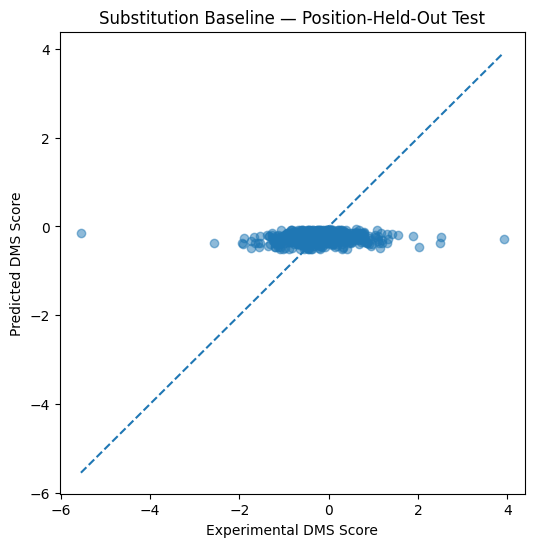

In [73]:
plt.figure(figsize=(6, 6))

plt.scatter(
    test_pos["DMS_score"],
    final_substitution_test_pred,
    alpha=0.5
)

min_value = min(
    test_pos["DMS_score"].min(),
    final_substitution_test_pred.min()
)

max_value = max(
    test_pos["DMS_score"].max(),
    final_substitution_test_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Experimental DMS Score")
plt.ylabel("Predicted DMS Score")
plt.title(
    "Substitution Baseline — Position-Held-Out Test"
)

plt.show()

In [74]:
primary_predictions = test_pos[
    [
        "mutant",
        "position",
        "DMS_score"
    ]
].copy()

primary_predictions[
    "predicted_substitution"
] = final_substitution_test_pred

primary_predictions[
    "predicted_substitution_position"
] = final_position_test_pred


PRIMARY_PREDICTIONS_PATH = (
    RESULTS_DIR / "baseline_position_test_predictions.csv"
)

primary_predictions.to_csv(
    PRIMARY_PREDICTIONS_PATH,
    index=False
)

print(
    "Saved:",
    PRIMARY_PREDICTIONS_PATH
)

Saved: C:\Users\subha\OneDrive\Desktop\Mandrake_Ai_Bio_research\Mandrake_Cas9_Assignment_Pack\Mandrake-Bio\results\baseline_position_test_predictions.csv


In [75]:
BASELINE_RESULTS_PATH = (
    RESULTS_DIR / "baseline_results.csv"
)

baseline_results.to_csv(
    BASELINE_RESULTS_PATH,
    index=False
)

print(
    "Saved:",
    BASELINE_RESULTS_PATH
)

Saved: C:\Users\subha\OneDrive\Desktop\Mandrake_Ai_Bio_research\Mandrake_Cas9_Assignment_Pack\Mandrake-Bio\results\baseline_results.csv


# Baseline Interpretation

The baseline models provide a reference point for the later pretrained
protein model.

The global mean provides the simplest possible prediction.

The substitution baseline asks whether the identity of the amino-acid change
alone contains useful information.

The substitution + position baseline additionally asks whether the numerical
location of the mutation along the Cas9 sequence provides useful predictive
information.

The primary position-held-out evaluation is the main benchmark because the
test positions were not observed during training.

The random mutation evaluation provides a secondary interpolation benchmark.

The next experiment will test whether pretrained protein sequence
representations provide information beyond these simple mutation-level
features.